# 🫀 Heart Disease Prediction — Gradient Boosting Classifier

**🇹🇷 Türkçe:**
Bu notebook, **UCI Heart Disease (Cleveland)** veri seti üzerinde bir hastada kalp hastalığı bulunup bulunmadığını (`target`: 1 / 0) tahmin eden bir **Gradient Boosting** sınıflandırıcısı kuruyor. Veri seti 303 hastaya ait 13 klinik ölçüm içeriyor.

**Gradient Boosting** ağaçları sırayla kurar ve her yeni ağacı bir öncekinin **hatasına** uydurur. Sınıflandırmada bu hata, olasılık uzayında değil **log-odds** uzayında hesaplanır: model her adımda log-odds tahminini düzeltir, sonuç sigmoid ile olasılığa çevrilir. AdaBoost'tan farkı, örnek ağırlıklarını değiştirmek yerine kayıp fonksiyonunun gradyanını takip etmesidir.

Notebook; keşifsel analiz, temel model, özellik önemi, `recall` odaklı `GridSearchCV` optimizasyonu ve ROC/AUC ile eşik analizini kapsıyor.

**🇬🇧 English:**
This notebook builds a **Gradient Boosting** classifier to predict the presence of heart disease (`target`: 1 / 0) on the **UCI Heart Disease (Cleveland)** dataset, which describes 303 patients with 13 clinical measurements.

**Gradient Boosting** builds trees sequentially, fitting each new tree to the **error** of the current ensemble. For classification that error lives in **log-odds** space rather than probability space: each step corrects the log-odds estimate, and a sigmoid maps the result back to a probability. Unlike AdaBoost, it follows the gradient of a loss function instead of re-weighting samples.

The notebook covers exploratory analysis, a baseline model, feature importances, `recall`-oriented tuning with `GridSearchCV`, and ROC/AUC threshold analysis.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme ve görselleştirme kütüphaneleri yükleniyor; scikit-learn bileşenleri kullanıldıkları adımın hemen öncesinde import ediliyor.

**🇬🇧 English:**
Data-handling and visualization libraries are loaded; scikit-learn components are imported immediately before the step that uses them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Veri seti CSV dosyasından okunuyor. Hedef değişken `target`: **1 = kalp hastalığı var**, 0 = yok.

| Kolon | Anlamı / Meaning | Tip / Type |
|---|---|---|
| `age` | Yaş / Age in years | sayısal / numeric |
| `sex` | Cinsiyet (1 = erkek, 0 = kadın) / Sex (1 = male, 0 = female) | ikili / binary |
| `cp` | Göğüs ağrısı tipi (0–3) / Chest pain type | **nominal** |
| `trestbps` | Dinlenme kan basıncı, mm Hg / Resting blood pressure | sayısal / numeric |
| `chol` | Serum kolesterol, mg/dl / Serum cholesterol | sayısal / numeric |
| `fbs` | Açlık kan şekeri > 120 mg/dl / Fasting blood sugar > 120 mg/dl | ikili / binary |
| `restecg` | Dinlenme EKG sonucu (0–2) / Resting ECG result | **nominal** |
| `thalach` | Ulaşılan maksimum kalp hızı / Maximum heart rate achieved | sayısal / numeric |
| `exang` | Egzersize bağlı anjina / Exercise-induced angina | ikili / binary |
| `oldpeak` | Egzersizle oluşan ST çökmesi / ST depression induced by exercise | sayısal / numeric |
| `slope` | ST segmentinin eğimi (0–2) / Slope of the peak exercise ST segment | **nominal** |
| `ca` | Floroskopiyle boyanan ana damar sayısı (0–4) / Major vessels coloured by fluoroscopy | sıralı / ordinal |
| `thal` | Talasemi tipi (0–3) / Thalassemia type | **nominal** |
| `target` | **Hedef:** 1 = hastalık var, 0 = yok / **Target:** 1 = disease, 0 = none | ikili / binary |

**🇬🇧 English:**
The dataset is read from CSV. The target is `target`: **1 = heart disease present**, 0 = absent.

In [2]:
df = pd.read_csv("../../Data/19-heart.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
303 satır, 14 kolon, tamamı sayısal tipte ve **eksik değer yok**. Hedef dağılımı 165 / 138 (%54 / %46) ile makul ölçüde dengeli — bu, doğruluk (accuracy) metriğinin en azından yanıltıcı olmadığı anlamına gelir, ancak ileride görüleceği gibi bu problem için yine de en uygun ölçüt değildir.

Önemli bir not: `cp`, `restecg`, `slope` ve `thal` kolonları tamsayı olarak saklanmıştır ama **nominal kategoriktir** — 0, 1, 2, 3 değerleri farklı türleri temsil eder, bir büyüklük sırası taşımaz.

**🇬🇧 English:**
303 rows, 14 columns, all stored as numeric types, with **no missing values**. The target is reasonably balanced at 165 / 138 (54% / 46%) — meaning accuracy is at least not misleading here, though as shown below it is still not the right metric for this problem.

An important note: `cp`, `restecg`, `slope` and `thal` are stored as integers but are **nominal categorical** — the values 0, 1, 2, 3 denote different types and carry no ordering.

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

## 📊 3. Keşifsel Veri Analizi / Exploratory Data Analysis

**🇹🇷 Türkçe:**
Her kolon için histogram çiziliyor. `sex`, `fbs`, `exang` ve `target` ikili (0/1) değişkenler olduğu için bunlarda histogram yalnızca iki çubuk üretir — bu kolonlar için `countplot` daha doğru bir araçtır; histogram burada hızlı bir genel bakış amacıyla kullanılmıştır.

**🇬🇧 English:**
A histogram is drawn for every column. Since `sex`, `fbs`, `exang` and `target` are binary (0/1), their histograms collapse to two bars — `countplot` is the more appropriate tool for those columns; histograms are used here only as a quick overview.

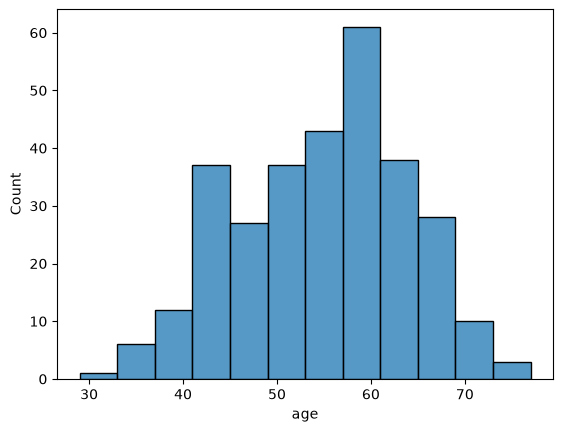

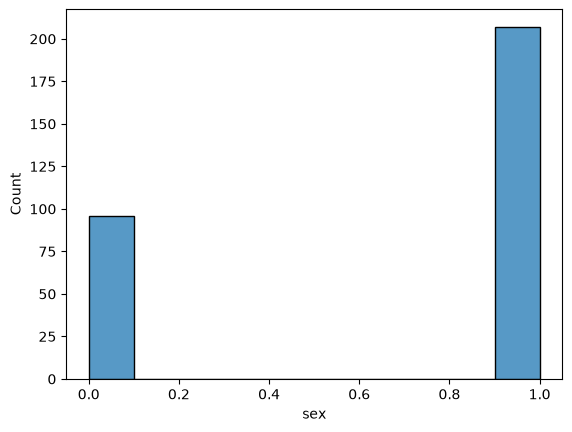

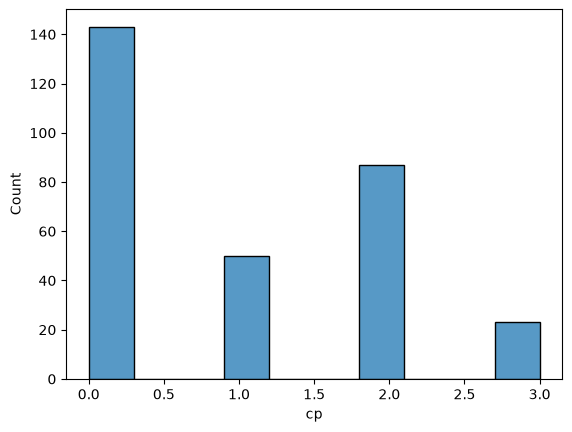

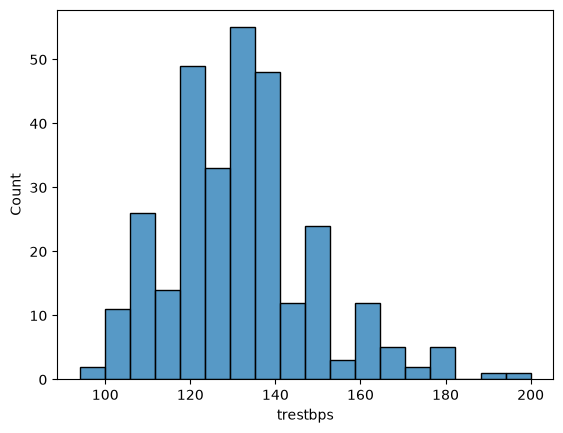

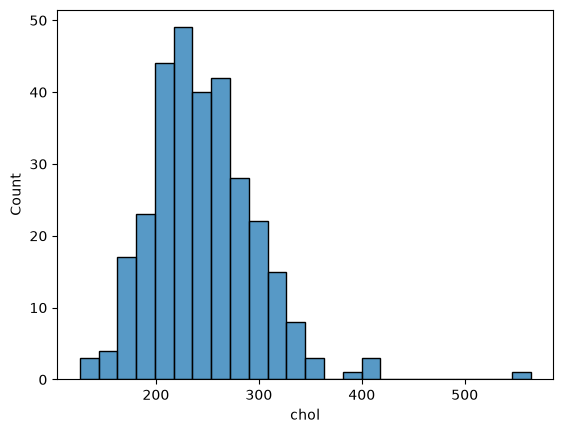

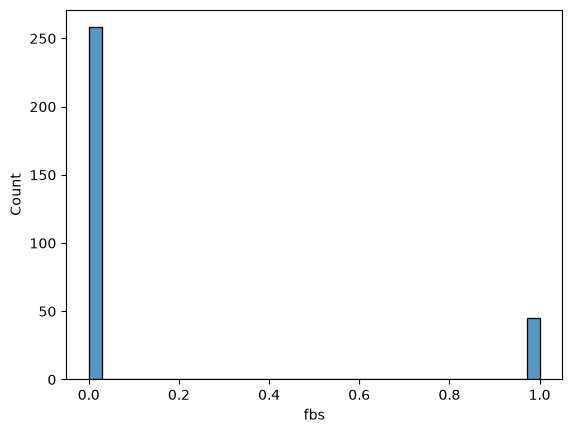

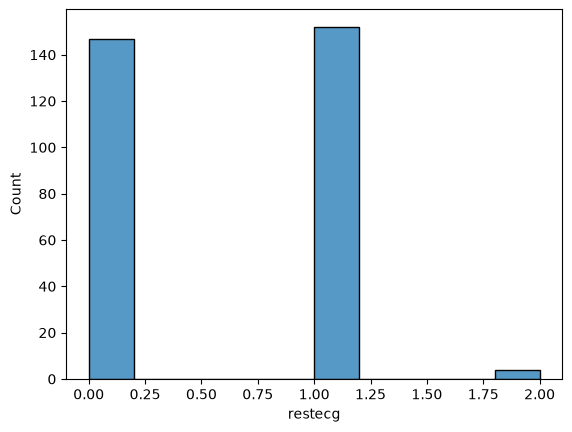

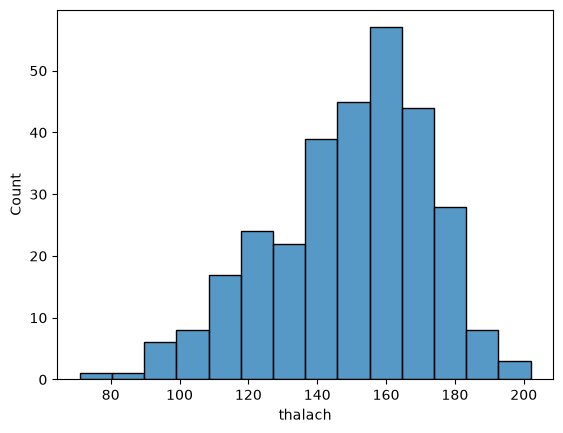

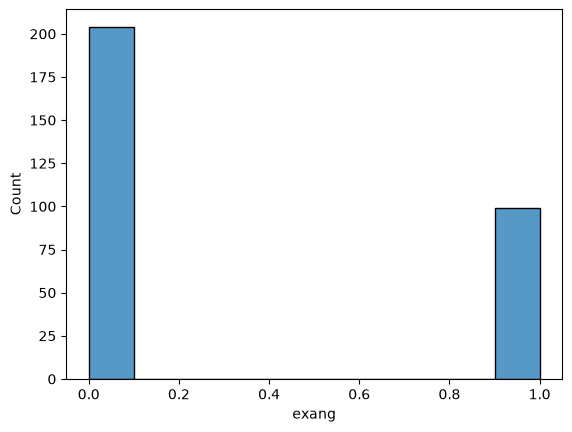

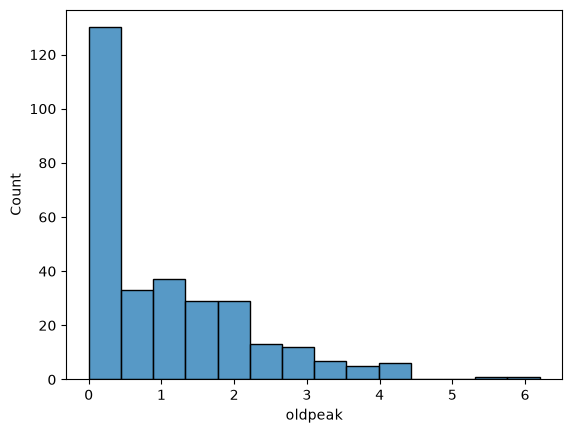

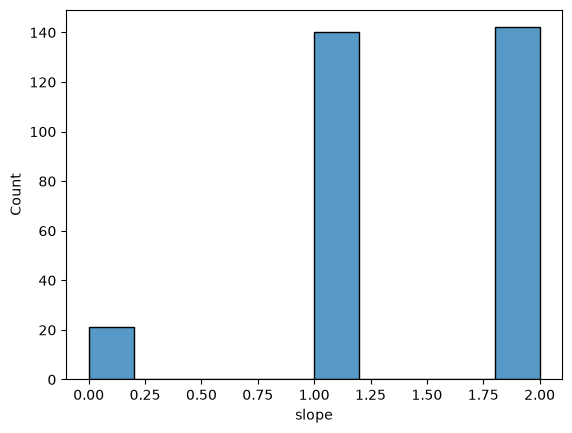

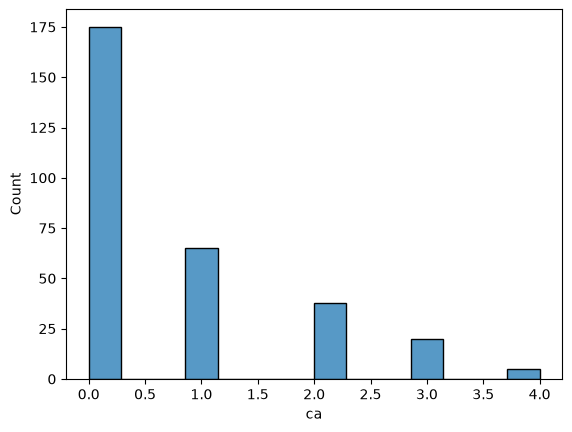

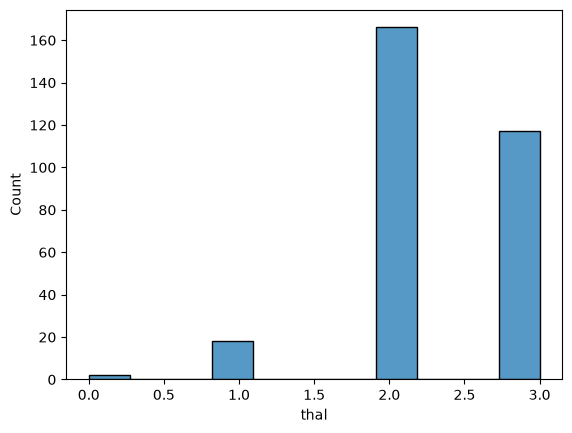

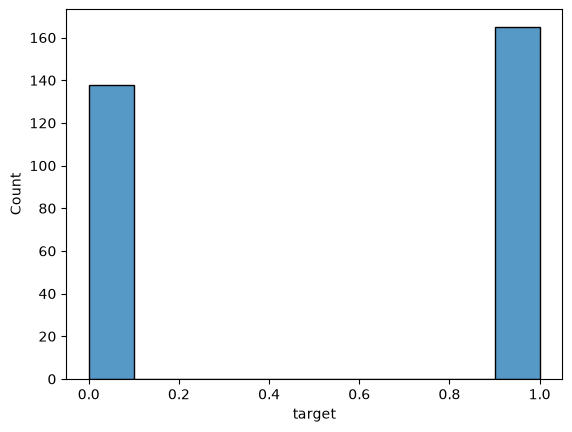

In [8]:
for col in df.columns:
    sns.histplot(df[col])
    plt.show()

### 3.2 Korelasyon Isı Haritası / Correlation Heatmap

**🇹🇷 Türkçe:**
Isı haritası tüm kolonlar arasındaki Pearson korelasyonunu gösteriyor. İki sınırı akılda tutmak gerekir:

1. **Nominal kolonlar için korelasyon anlamsızdır.** `cp`, `restecg`, `slope` ve `thal` için hesaplanan sayı matematiksel olarak üretilebilir ama yorumlanamaz — "`cp=3`, `cp=1`'in üç katı" diye bir şey yoktur. Bu kolonlar için grafiğe temkinli bakılmalıdır.
2. **Pearson yalnızca doğrusal ilişkiyi ölçer.** Bu nedenle korelasyon sıralaması, ilerideki `feature_importances_` sıralamasıyla birebir örtüşmek zorunda değildir.

**🇬🇧 English:**
The heatmap shows Pearson correlations across all columns. Two limitations are worth keeping in mind:

1. **Correlation is meaningless for nominal columns.** A number can be computed for `cp`, `restecg`, `slope` and `thal`, but it cannot be interpreted — "`cp=3` is three times `cp=1`" is not a meaningful statement. Read those cells with caution.
2. **Pearson measures only linear association**, so the correlation ranking need not match the `feature_importances_` ranking later in the notebook.

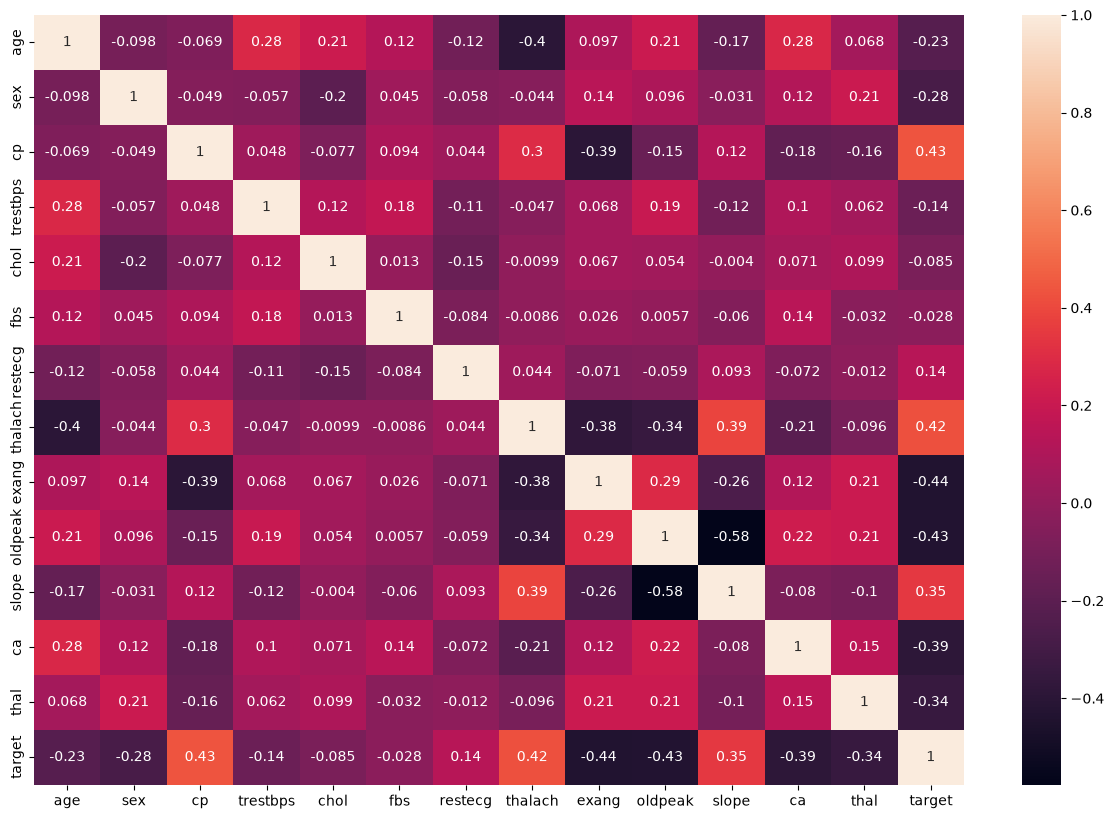

In [9]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

## 🎯 4. Özellik ve Hedef Ayrımı / Feature–Target Split

**🇹🇷 Türkçe:**
`target` hedef değişken olarak ayrılıyor; kalan 13 klinik ölçüm özellik matrisi `X`'i oluşturuyor. Ağaç tabanlı bir model kullanıldığı için ölçekleme uygulanmıyor — ağaçlar eşik karşılaştırması yaptığından değişken ölçeğine duyarsızdır.

**🇬🇧 English:**
`target` is separated as the label and the remaining 13 clinical measurements form the feature matrix `X`. No scaling is applied: the model is tree-based, and trees compare thresholds, making them invariant to feature scale.

In [10]:
X = df.drop('target', axis=1)
y = df['target']

In [11]:
from sklearn.model_selection import train_test_split

## ✂️ 5. Train/Test Ayrımı / Train-Test Split

**🇹🇷 Türkçe:**
Veri %80 eğitim / %20 test olarak bölünüyor. `stratify=y` kullanılıyor: bu, sınıf oranının (%54 / %46) hem eğitim hem test kümesinde korunmasını garanti eder. 303 satırlık bir veri setinde stratifikasyon olmadan bölünme şansa kalır ve test kümesi kolayca dengesiz düşebilir.

Test kümesi yalnızca **61 örnek** içeriyor.

Bu küçüklük, sonuçların okunma biçimini doğrudan etkiler: test kümesinde tek bir örnek `1/61 = 0.0164` accuracy'ye karşılık gelir. Yani iki model arasındaki 0.02'lik bir fark, tek bir hastanın doğru ya da yanlış tahmin edilmesinden ibarettir. Aynı model yalnızca `random_state` değiştirilerek 15 farklı bölünmeyle çalıştırıldığında test accuracy'si **0.738 ile 0.869 arasında** dalgalanmaktadır (standart sapma ≈ 0.046). Bu nedenle bu notebook'ta tek bir test skoru değil, **çapraz doğrulama skoru** birincil ölçüt olarak alınmalıdır.

**🇬🇧 English:**
The data is split 80/20 with `stratify=y`, which guarantees the class ratio (54% / 46%) is preserved in both the training and the test set. On a 303-row dataset an unstratified split is left to chance and can easily produce an unbalanced test set.

The test set holds only **61 samples**.

That size directly shapes how the results should be read: one sample is worth `1/61 = 0.0164` accuracy, so a 0.02 gap between two models amounts to a single patient being classified differently. Running the same model across 15 different splits (varying only `random_state`) produces test accuracies between **0.738 and 0.869** (standard deviation ≈ 0.046). The **cross-validated score**, not a single test score, should therefore be treated as the primary metric here.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 🌲 6. Gradient Boosting Sınıflandırıcısı / The Gradient Boosting Classifier

**🇹🇷 Türkçe:**
`GradientBoostingClassifier` varsayılan parametrelerle (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`) kuruluyor.

Sınıflandırmada algoritma şu döngüyü izler:
1. Sabit bir log-odds tahminiyle başla (sınıf oranının logiti).
2. Kayıp fonksiyonunun (`log_loss`) gradyanını hesapla — bu, olasılık uzayındaki hataya karşılık gelir.
3. Bu gradyana sığ bir regresyon ağacı uydur.
4. Ağacın katkısını `learning_rate` ile ölçekleyip log-odds tahminine ekle.
5. Sigmoid ile olasılığa çevir ve tekrarla.

**🇬🇧 English:**
A `GradientBoostingClassifier` is fitted with defaults (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`).

For classification the algorithm follows this loop:
1. Start from a constant log-odds estimate (the logit of the class ratio).
2. Compute the gradient of the loss (`log_loss`) — the error in probability space.
3. Fit a shallow regression tree to that gradient.
4. Scale the tree's contribution by `learning_rate` and add it to the log-odds estimate.
5. Map back to a probability with the sigmoid and repeat.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

In [14]:
gb_cls = GradientBoostingClassifier(random_state=42)

In [15]:
gb_cls.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [16]:
y_pred = gb_cls.predict(X_test)

## 📏 7. Model Değerlendirme / Model Evaluation

**🇹🇷 Türkçe:**
Karışıklık matrisi ve sınıflandırma raporu inceleniyor. Bu problemde **accuracy tek başına yetersiz bir ölçüttür** ve karışıklık matrisinin hangi hücresine bakıldığı önemlidir:

- **Yanlış negatif (FN)** — gerçekte kalp hastası olan bir hastaya "sağlam" demek. Klinik olarak en pahalı hata budur; hasta tedavi görmeden eve gönderilir.
- **Yanlış pozitif (FP)** — sağlam bir kişiye "hasta" demek. Sonucu gereksiz ileri tetkiktir; rahatsız edicidir ama geri döndürülebilir.

Temel model %82 accuracy veriyor, pozitif sınıf recall'ü 0.91 ve **3 hasta kaçırıyor**. Bu asimetri nedeniyle bu notebook'ta pozitif sınıfın **recall** değeri (hastaların kaçının yakalandığı) accuracy'den daha belirleyici kabul edilmiştir.

**🇬🇧 English:**
The confusion matrix and classification report are examined. For this problem **accuracy alone is an inadequate metric**, and which cell of the confusion matrix is read matters:

- **False negative (FN)** — telling a patient who does have heart disease that they are healthy. Clinically this is the expensive error: the patient goes home untreated.
- **False positive (FP)** — flagging a healthy person as diseased. The consequence is unnecessary further testing: unpleasant, but recoverable.

The baseline model reaches 82% accuracy with a positive-class recall of 0.91, **missing 3 patients**. Because of this asymmetry, the positive class's **recall** (how many true patients are caught) is treated here as more decisive than accuracy.

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[20  8]
 [ 3 30]]
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

0.819672131147541


## 🔎 8. Özellik Önemleri / Feature Importances

**🇹🇷 Türkçe:**
`feature_importances_` ile en belirleyici klinik ölçümler sıralanıyor. Öne çıkan değişkenler — göğüs ağrısı tipi (`cp`, 0.28), talasemi tipi (`thal`, 0.15), egzersizle oluşan ST çökmesi (`oldpeak`, 0.13) ve floroskopiyle boyanan damar sayısı (`ca`, 0.09) — kardiyoloji literatüründeki bilinen risk göstergeleriyle uyumludur; bu, modelin veri setindeki rastgele örüntülere değil gerçek klinik sinyale dayandığına dair bir işarettir.

**Uyarı:** Safsızlık tabanlı özellik önemi, çok sayıda farklı değer alan sürekli değişkenleri kayırma eğilimindedir. Sağlam bir doğrulama için `permutation_importance` ile karşılaştırılması önerilir.

**🇬🇧 English:**
`feature_importances_` ranks the most decisive clinical measurements. The leading variables — chest pain type (`cp`, 0.28), thalassemia type (`thal`, 0.15), exercise-induced ST depression (`oldpeak`, 0.13) and vessels coloured by fluoroscopy (`ca`, 0.09) — line up with established cardiological risk markers, which is evidence that the model is keying on real clinical signal rather than dataset-specific noise.

**Caveat:** impurity-based importance tends to favour high-cardinality continuous features; cross-checking with `permutation_importance` is recommended for a robust reading.

In [19]:
pd.Series(gb_cls.feature_importances_, index=X.columns).sort_values(ascending=False).head()

cp         0.280899
thal       0.148306
oldpeak    0.130482
ca         0.089120
chol       0.073432
dtype: float64

## 🔧 9. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
5 katlı çapraz doğrulama ile `n_estimators`, `max_depth`, `learning_rate` ve `loss` üzerinde bir `GridSearchCV` çalıştırılıyor.

**Skor ölçütü olarak bilinçli biçimde `recall` seçilmiştir.** `accuracy` ile optimize etmek, aramanın yanlış negatifleri yanlış pozitiflerle eşit maliyette görmesi anlamına gelirdi — oysa tıbbi tarama bağlamında kaçırılan hasta çok daha pahalıdır. `recall` ile arama, kaçan hasta sayısını azaltan kombinasyonları ödüllendirir.

`loss` seçenekleri de kavramsal olarak ilginçtir: `log_loss` standart lojistik kayıptır, `exponential` ise Gradient Boosting'i matematiksel olarak **AdaBoost'a denk** hale getirir — yani aynı sınıf üzerinden iki farklı boosting algoritması karşılaştırılmış olur.

**🇬🇧 English:**
A 5-fold `GridSearchCV` searches `n_estimators`, `max_depth`, `learning_rate` and `loss`.

**`recall` is chosen deliberately as the scoring metric.** Optimizing `accuracy` would have told the search that a false negative costs the same as a false positive — but in a medical screening context a missed patient is far more expensive. Scoring by `recall` rewards the combinations that reduce missed cases.

The `loss` options are conceptually interesting too: `log_loss` is the standard logistic loss, while `exponential` makes Gradient Boosting mathematically **equivalent to AdaBoost** — so the grid effectively compares two boosting algorithms through one estimator class.

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
params = {
    "n_estimators": [50,100,150],
    "max_depth": [3,4,5],
    "learning_rate": [0.01,0.05,0.1,0.3,0.5],
    "loss": ["log_loss", "exponential"]
}

grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=params,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

In [22]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

### 9.2 Ayarlanmış Model Sonuçları / Tuned Model Results

**🇹🇷 Türkçe:**
`recall` ile optimize etmek amacına ulaşıyor: **kaçırılan hasta sayısı 3'ten 1'e düşüyor**, pozitif sınıf recall'ü **0.91 → 0.97** yükseliyor. Beklendiği gibi bedeli yanlış pozitiflerde ödeniyor (8 → 9) ve `0` sınıfının recall'ü 0.71'den 0.68'e geriliyor; accuracy ise 0.82'den 0.84'e çıkıyor. Seçilen kombinasyon (`learning_rate=0.01`, `n_estimators=100`, `max_depth=3`, `loss="log_loss"`) oldukça muhafazakârdır — 303 satırlık bir veri setinde daha agresif ayarların ezberlemeye gittiğinin işaretidir.

Karşılaştırma yapılırken 61 örneklik test kümesinin sınırı hatırlanmalıdır: birkaç yüzde puanlık farklar tek tek hastalara karşılık gelir ve `grid.best_score_` (243 örnek üzerinde 5 katlı çapraz doğrulama) daha güvenilir bir karşılaştırma tabanıdır.

**🇬🇧 English:**
Optimizing for `recall` does what it was asked to do: **missed patients drop from 3 to 1** and positive-class recall rises **0.91 → 0.97**. The cost lands on false positives as expected (8 → 9), pushing class `0` recall from 0.71 down to 0.68, while accuracy improves from 0.82 to 0.84. The selected combination (`learning_rate=0.01`, `n_estimators=100`, `max_depth=3`, `loss="log_loss"`) is notably conservative — a sign that on a 303-row dataset more aggressive settings tip into memorization.

The 61-sample test set's limits should be kept in mind when reading that comparison: differences of a few percentage points correspond to individual patients, and `grid.best_score_` (5-fold cross-validation over 243 samples) is the more reliable basis for comparison.

In [23]:
y_pred_grid = grid.predict(X_test)

In [24]:
print(classification_report(y_test, y_pred_grid))
print(confusion_matrix(y_test, y_pred_grid))
print(accuracy_score(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61

[[19  9]
 [ 1 32]]
0.8360655737704918


In [25]:
grid.best_params_

{'learning_rate': 0.01,
 'loss': 'log_loss',
 'max_depth': 3,
 'n_estimators': 100}

## 📈 10. ROC Eğrisi, AUC ve Karar Eşiği / ROC Curve, AUC and the Decision Threshold

**🇹🇷 Türkçe:**
`predict()` her zaman 0 veya 1 döndürür, ancak model içeride bir **olasılık** üretir. `predict()` bu olasılığı varsayılan **0.5** eşiğinden keser — ve 0.5 evrensel bir doğru değil, yalnızca bir varsayılandır:

```python
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
```

Eşiği değiştirmek modeli yeniden eğitmeden duyarlılığı ayarlamayı sağlar ve doğrudan bir **takas** yaratır: eşik düşürüldüğünde daha az hasta kaçırılır (recall artar) ama daha çok yanlış alarm verilir (precision düşer).

**ROC eğrisi** bu takası tüm olası eşikler için tek grafikte gösterir. Dikey eksen **TPR** (recall — yakalanan hastaların oranı), yatay eksen **FPR** (yanlışlıkla hasta denen sağlamların oranı). Eğri üzerindeki her nokta bir eşiktir; eğri sol üst köşeye ne kadar yakınsa model o kadar iyidir, köşegen ise rastgele tahmini temsil eder.

**AUC** eğrinin altındaki alandır ve tek bir eşikten bağımsız özet verir. Sezgisel yorumu: *rastgele seçilen bir hastaya, rastgele seçilen bir sağlamdan daha yüksek olasılık atama ihtimali.* Bu özelliğiyle AUC, küçük test kümelerinde accuracy'den daha kararlı bir ölçüttür.

**🇬🇧 English:**
`predict()` always returns 0 or 1, but the model internally produces a **probability**. `predict()` simply thresholds it at the default **0.5** — which is a default, not a universal truth:

```python
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
```

Moving the threshold tunes sensitivity without retraining, and creates a direct **trade-off**: lowering it misses fewer patients (higher recall) at the cost of more false alarms (lower precision).

The **ROC curve** displays that trade-off across every possible threshold at once. The vertical axis is **TPR** (recall — the fraction of true patients caught), the horizontal axis is **FPR** (the fraction of healthy people wrongly flagged). Every point on the curve is one threshold; the closer the curve hugs the top-left corner the better the model, while the diagonal represents random guessing.

**AUC** is the area under that curve, summarizing performance independently of any single threshold. Its intuitive reading: *the probability that a randomly chosen patient is scored higher than a randomly chosen healthy person.* This makes AUC a more stable metric than accuracy on small test sets.

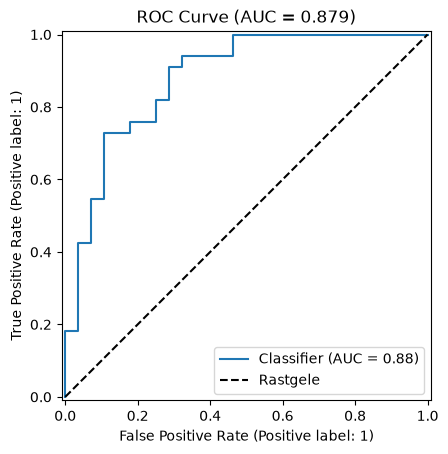

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

y_proba = gb_cls.predict_proba(X_test)[:, 1]   # sadece sütun 1
auc = roc_auc_score(y_test, y_proba)

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele')   # köşegen referans
plt.title(f'ROC Curve (AUC = {auc:.3f})')
plt.legend()
plt.show()

## 🏁 11. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- Gradient Boosting sınıflandırıcısı 13 klinik ölçümden kalp hastalığını **AUC ≈ 0.88** ile ayırt ediyor; en belirleyici değişkenler `cp`, `thal`, `oldpeak` ve `ca`.
- Notebook'un birinci metodolojik dersi **metrik seçiminin bir alan bilgisi kararı olduğudur.** Tıbbi taramada yanlış negatif, yanlış pozitiften çok daha pahalıdır; bu yüzden `GridSearchCV` `accuracy` yerine `recall` ile optimize edilmiş ve kaçırılan hasta sayısı 3'ten 1'e düşürülmüştür.
- İkinci ders **karar eşiğinin bir hiperparametre olduğudur.** `predict()`'in varsayılan 0.5 eşiği bir seçimdir, veri tarafından dayatılmış bir gerçek değil; `predict_proba` ile eşik ayarlanarak recall, modeli yeniden eğitmeden yükseltilebilir.
- Üçüncü ders **küçük test kümelerinin sınırıdır.** 61 örneklik bir test kümesinde tek hasta 0.016 accuracy eder ve skorlar farklı bölünmelerde ±0.05 dalgalanır; bu koşullarda çapraz doğrulama skoru ve AUC, tek bir test accuracy'sinden çok daha güvenilirdir.

**🇬🇧 English:**
- The Gradient Boosting classifier separates heart disease from 13 clinical measurements at **AUC ≈ 0.88**, with `cp`, `thal`, `oldpeak` and `ca` as the dominant predictors.
- The notebook's first methodological lesson is that **choosing a metric is a domain decision.** In medical screening a false negative costs far more than a false positive, which is why `GridSearchCV` optimizes `recall` rather than `accuracy` — cutting missed patients from 3 to 1.
- The second lesson is that **the decision threshold is a hyperparameter.** The 0.5 cut-off inside `predict()` is a choice, not a fact imposed by the data; tuning it through `predict_proba` raises recall without retraining the model.
- The third lesson is **the limit of a small test set.** With 61 samples one patient is worth 0.016 accuracy and scores swing by roughly ±0.05 across splits; under those conditions the cross-validated score and AUC are far more trustworthy than a single test accuracy.